# 02 · EDA: the six history tables

**Goal:** check that the tables link together correctly, see how many applicants each table covers,
and find the strange values we must clean. Tables are loaded one at a time (only the needed columns)
to keep memory low. Run all cells from top to bottom (takes about 1–2 minutes).

In [1]:
%load_ext autoreload
%autoreload 2

import gc

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from creditrisk.config import PROJECT_ROOT, get_path, set_seed

SEED = set_seed()
INTERIM, FIG = get_path("interim"), get_path("figures")
sns.set_theme(style="whitegrid", context="notebook")
facts = {}

HISTORY = ["bureau", "bureau_balance", "previous_application",
           "installments_payments", "pos_cash_balance", "credit_card_balance"]


def load(name, columns=None):
    """Load one Parquet table, optionally only some columns."""
    return pd.read_parquet(INTERIM / f"{name}.parquet", columns=columns)


def save(fig, name):
    fig.savefig(FIG / name, dpi=150, bbox_inches="tight")
    print(f"saved reports/figures/{name}")


train = load("application_train", ["SK_ID_CURR", "TARGET"])
test_ids = load("application_test", ["SK_ID_CURR"])["SK_ID_CURR"]
print("train applicants:", len(train), "| test applicants:", len(test_ids))

train applicants: 307511 | test applicants: 48744


## 1. Keys are unique and train/test don't overlap

In [2]:
checks = {
    "application_train: SK_ID_CURR unique": train["SK_ID_CURR"].is_unique,
    "application_test: SK_ID_CURR unique": test_ids.is_unique,
    "bureau: SK_ID_BUREAU unique": load("bureau", ["SK_ID_BUREAU"])["SK_ID_BUREAU"].is_unique,
    "previous_application: SK_ID_PREV unique":
        load("previous_application", ["SK_ID_PREV"])["SK_ID_PREV"].is_unique,
    "no SK_ID_CURR in both train and test":
        np.intersect1d(train["SK_ID_CURR"], test_ids).size == 0,
}
for name, ok in checks.items():
    print(f"{'OK  ' if ok else 'FAIL'}  {name}")
facts["all_key_checks_passed"] = all(checks.values())

OK    application_train: SK_ID_CURR unique
OK    application_test: SK_ID_CURR unique
OK    bureau: SK_ID_BUREAU unique
OK    previous_application: SK_ID_PREV unique
OK    no SK_ID_CURR in both train and test


## 2. Coverage: how many applicants appear in each table?
`bureau_balance` has no `SK_ID_CURR`, so it is linked through `bureau` (`SK_ID_BUREAU` → `SK_ID_CURR`).

,% train applicants covered,default % with,default % without
table,,,
bureau,85.7,7.73,10.12
bureau_balance,30.0,8.14,8.04
previous_application,94.6,8.19,5.96
installments_payments,94.8,8.19,5.98
pos_cash_balance,94.1,8.16,6.66
credit_card_balance,28.3,8.67,7.84


saved reports/coverage.csv
saved reports/figures/fig10_table_coverage.png


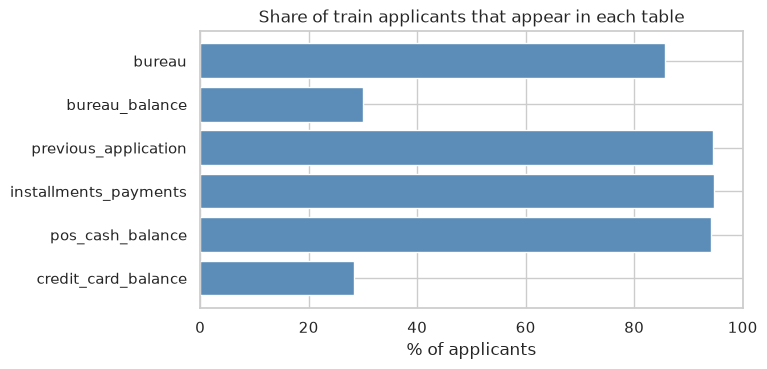

In [3]:
ids_in = {}
for name in ["bureau", "previous_application", "installments_payments",
             "pos_cash_balance", "credit_card_balance"]:
    ids = load(name, ["SK_ID_CURR"])["SK_ID_CURR"]
    ids_in[name] = (ids.unique(), len(ids))

bureau_keys = load("bureau", ["SK_ID_CURR", "SK_ID_BUREAU"])
bb_bureau_ids = load("bureau_balance", ["SK_ID_BUREAU"])["SK_ID_BUREAU"].unique()
has_bb = bureau_keys["SK_ID_BUREAU"].isin(bb_bureau_ids)
ids_in["bureau_balance"] = (bureau_keys.loc[has_bb, "SK_ID_CURR"].unique(), None)
facts["%_bureau_loans_with_monthly_rows"] = round(100 * has_bb.mean(), 1)
facts["%_bureau_balance_loans_not_in_bureau"] = round(
    100 * (~pd.Series(bb_bureau_ids).isin(bureau_keys["SK_ID_BUREAU"])).mean(), 1)

rows = []
for name in HISTORY:
    unique_ids, n_rows = ids_in[name]
    has = train["SK_ID_CURR"].isin(unique_ids)
    rows.append({
        "table": name,
        "% train applicants covered": round(100 * has.mean(), 1),
        "default % with": round(100 * train.loc[has, "TARGET"].mean(), 2),
        "default % without": round(100 * train.loc[~has, "TARGET"].mean(), 2),
    })
coverage = pd.DataFrame(rows).set_index("table")
coverage.to_csv(PROJECT_ROOT / "reports" / "coverage.csv")
facts["coverage_%"] = coverage["% train applicants covered"].to_dict()
display(coverage)
print("saved reports/coverage.csv")
del bureau_keys
gc.collect()

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.barh(coverage.index[::-1], coverage["% train applicants covered"][::-1], color="#5B8DB8")
ax.set(title="Share of train applicants that appear in each table",
       xlabel="% of applicants", xlim=(0, 100))
save(fig, "fig10_table_coverage.png")

## 3. Missing values, DAYS_* ranges and the 365243 code, table by table
Look for impossible values (for example end dates more than 100 years ago) and for the fake 365243 code.

In [4]:
for name in HISTORY:
    df = load(name)
    print(f"\n=== {name}: {df.shape[0]:,} rows x {df.shape[1]} cols ===")
    miss = (100 * df.isna().mean()).round(1)
    miss = miss[miss > 0].sort_values(ascending=False)
    if len(miss):
        display(miss.rename("missing %").to_frame())
    else:
        print("no missing values")
    day_cols = [c for c in df.columns if c.startswith(("DAYS_", "MONTHS_"))]
    if day_cols:
        ranges = df[day_cols].agg(["min", "max"]).T
        ranges["count of 365243"] = (df[day_cols] == 365243).sum()
        per_year = [12 if c.startswith("MONTHS_") else 365.25 for c in ranges.index]
        ranges["min in years"] = (ranges["min"] / per_year).round(1)
        display(ranges)
        has_code = ranges["count of 365243"] > 0
        facts[f"{name}: columns with 365243"] = list(ranges.index[has_code])
    del df
    gc.collect()


=== bureau: 1,716,428 rows x 17 cols ===


,missing %
AMT_ANNUITY,71.5
AMT_CREDIT_MAX_OVERDUE,65.5
DAYS_ENDDATE_FACT,36.9
AMT_CREDIT_SUM_LIMIT,34.5
AMT_CREDIT_SUM_DEBT,15.0
DAYS_CREDIT_ENDDATE,6.1


,min,max,count of 365243,min in years
DAYS_CREDIT,-2922.0,0.0,0,-8.0
DAYS_CREDIT_ENDDATE,-42060.0,31199.0,0,-115.2
DAYS_ENDDATE_FACT,-42023.0,0.0,0,-115.1
DAYS_CREDIT_UPDATE,-41947.0,372.0,0,-114.8



=== bureau_balance: 27,299,925 rows x 3 cols ===
no missing values


,min,max,count of 365243,min in years
MONTHS_BALANCE,-96,0,0,-8.0


...

,missing %
CNT_INSTALMENT,0.3
CNT_INSTALMENT_FUTURE,0.3


,min,max,count of 365243,min in years
MONTHS_BALANCE,-96,-1,0,-8.0



=== credit_card_balance: 3,840,312 rows x 23 cols ===


,missing %
AMT_PAYMENT_CURRENT,20.0
AMT_DRAWINGS_ATM_CURRENT,19.5
AMT_DRAWINGS_OTHER_CURRENT,19.5
AMT_DRAWINGS_POS_CURRENT,19.5
CNT_DRAWINGS_ATM_CURRENT,19.5
CNT_DRAWINGS_POS_CURRENT,19.5
CNT_DRAWINGS_OTHER_CURRENT,19.5
AMT_INST_MIN_REGULARITY,7.9
CNT_INSTALMENT_MATURE_CUM,7.9


,min,max,count of 365243,min in years
MONTHS_BALANCE,-96,-1,0,-8.0


## 4. Status values

In [5]:
status_columns = [
    ("bureau", "CREDIT_ACTIVE"),
    ("bureau_balance", "STATUS"),
    ("previous_application", "NAME_CONTRACT_STATUS"),
    ("pos_cash_balance", "NAME_CONTRACT_STATUS"),
]
for name, col in status_columns:
    vc = load(name, [col])[col].value_counts()
    vc = vc[vc > 0]
    table = pd.DataFrame({"rows": vc, "%": (100 * vc / vc.sum()).round(2)})
    print(f"\n{name}.{col}")
    display(table)
    facts[f"{name}.{col} %"] = table["%"].to_dict()


bureau.CREDIT_ACTIVE


,rows,%
CREDIT_ACTIVE,,
Closed,1079273,62.88
Active,630607,36.74
Sold,6527,0.38
Bad debt,21,0.00



bureau_balance.STATUS


,rows,%
STATUS,,
C,13646993,49.99
0,7499507,27.47
X,5810482,21.28
1,242347,0.89
5,62406,0.23
2,23419,0.09
3,8924,0.03
4,5847,0.02



previous_application.NAME_CONTRACT_STATUS


,rows,%
NAME_CONTRACT_STATUS,,
Approved,1036781,62.07
Canceled,316319,18.94
Refused,290678,17.40
Unused offer,26436,1.58



pos_cash_balance.NAME_CONTRACT_STATUS


,rows,%
NAME_CONTRACT_STATUS,,
Active,9151119,91.50
Completed,744883,7.45
Signed,87260,0.87
Demand,7065,0.07
Returned to the store,5461,0.05
Approved,4917,0.05
Amortized debt,636,0.01
Canceled,15,0.00
XNA,2,0.00


## Key facts
Copy these numbers into your Findings below.

In [6]:
for key, value in facts.items():
    print(f"{key:<45} {value}")

all_key_checks_passed                         True
%_bureau_loans_with_monthly_rows              45.1
%_bureau_balance_loans_not_in_bureau          5.3
coverage_%                                    {'bureau': 85.7, 'bureau_balance': 30.0, 'previous_application': 94.6, 'installments_payments': 94.8, 'pos_cash_balance': 94.1, 'credit_card_balance': 28.3}
bureau: columns with 365243                   []
bureau_balance: columns with 365243           []
previous_application: columns with 365243     ['DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_LAST_DUE', 'DAYS_TERMINATION']
installments_payments: columns with 365243    []
pos_cash_balance: columns with 365243         []
credit_card_balance: columns with 365243      []
bureau.CREDIT_ACTIVE %                        {'Closed': 62.88, 'Active': 36.74, 'Sold': 0.38, 'Bad debt': 0.0}
bureau_balance.STATUS %                       {'C': 49.99, '0': 27.47, 'X': 21.28, '1': 0.89, '5': 0.23, '2': 0.09, '3': 0.03, '4': 0.0

## Findings

- **Keys:** all checks passed. IDs are unique in every table and no applicant is in both train and test.
- **Coverage of train applicants:** previous applications 94.6%, installments 94.8%, POS/cash 94.1%, bureau 85.7%, bureau_balance 30.0%, credit cards 28.3%.
- **No credit history:** applicants without bureau records default at 10.12% vs 7.73% with records.
- **Unmatched old loans:** installments cover more applicants (94.8%) than previous_application (94.6%), so some loans in the payment tables have no matching previous application.
- **bureau_balance:** only 45.1% of bureau loans have monthly rows, and 5.3% of the loans in bureau_balance do not exist in bureau.
- **The 365243 code** appears only in previous_application: DAYS_FIRST_DRAWING, DAYS_FIRST_DUE, DAYS_LAST_DUE_1ST_VERSION, DAYS_LAST_DUE, DAYS_TERMINATION.
- **Bureau loans:** 62.88% closed, 36.74% active, 0.38% sold; "bad debt" is almost zero.
- **Monthly bureau status:** 49.99% closed (C), 27.47% on time (0), 21.28% unknown (X); late months (1–5) are about 1.3% in total.
- **Previous applications:** 62.07% approved, 18.94% canceled, 17.40% refused, 1.58% unused offers.
- **POS/cash loans:** 91.5% of monthly rows are active and 7.45% completed; risky statuses like "Demand" are rare (0.07%).

## Decisions

- previous_application: 365243 → NaN in the five DAYS_ columns listed above.
- Payment tables (installments, POS, credit card): summarise with their own SK_ID_CURR column, not through previous_application, so unmatched loans are not lost.
- bureau_balance: summarise per bureau loan first, then join to bureau; the 5.3% unmatched loans drop out.
- bureau: combine "Sold" and "Bad debt" into one flag, because bad debt alone is too rare.
- After joining: count features → 0 for applicants with no rows; means and ratios stay NaN; add has_* flags.
- bureau_balance and credit card features are empty for about 70% of applicants; the ablation study will show whether they help.
- Impossible DAYS_ values found: __ → set to NaN.